# Question 2: House Prices - Advanced Regression Techniques

This notebook builds two Kaggle-ready regression submissions for the **House Prices - Advanced Regression Techniques** competition. The workflow includes data cleaning, dichotomous variables, interactions, polynomial terms, subset investigation, transformations, dimension reduction, model interpretation, assumption diagnostics, and Kaggle submission files.

## 1. Setup and Competition Files

The competition target is `SalePrice`, and the Kaggle submission must contain `Id` and predicted `SalePrice`. The evaluation metric is based on the error between the logarithm of predicted and observed sale prices, so this notebook models `log1p(SalePrice)` and converts predictions back with `expm1`.

In [2]:
# Core libraries
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import ElasticNetCV, RidgeCV, Ridge, LassoCV, LinearRegression
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
from sklearn.base import clone

from scipy import stats
try:
    import statsmodels.api as sm
    from statsmodels.stats.diagnostic import het_breuschpagan
    HAS_STATSMODELS = True
except Exception:
    HAS_STATSMODELS = False

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)

# Kaggle path; this also works locally if files are placed in ./input/
KAGGLE_PATH = '/kaggle/input/competitions/house-prices-advanced-regression-techniques'
LOCAL_PATH = './input'
DATA_PATH = KAGGLE_PATH if os.path.exists(KAGGLE_PATH) else LOCAL_PATH
print('Using DATA_PATH:', DATA_PATH)

Using DATA_PATH: /kaggle/input/competitions/house-prices-advanced-regression-techniques


In [3]:
train = pd.read_csv(os.path.join(DATA_PATH, 'train.csv'))
test = pd.read_csv(os.path.join(DATA_PATH, 'test.csv'))
sample_submission = pd.read_csv(os.path.join(DATA_PATH, 'sample_submission.csv'))

print('Train shape:', train.shape)
print('Test shape:', test.shape)
display(train.head())
display(test.head())

Train shape: (1460, 81)
Test shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


## 2. Dataset Summary and Target Transformation

The dataset contains structured Ames housing observations with many numeric and categorical predictors. Since expensive homes can create high-leverage effects and the Kaggle metric is log-based, the target is transformed using `log1p(SalePrice)`.

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


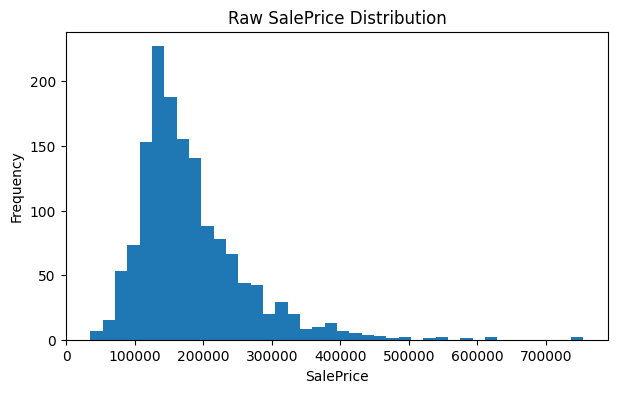

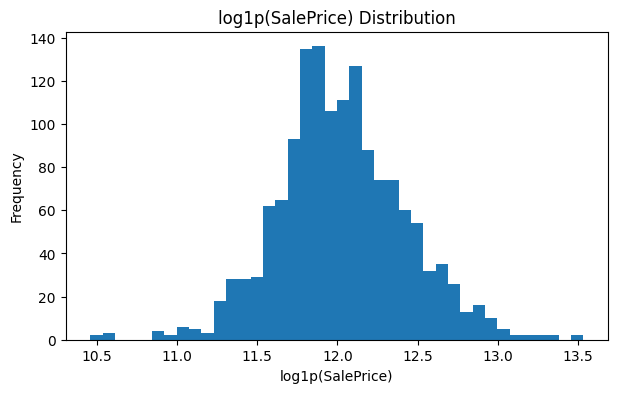

Raw SalePrice skew: 1.8828757597682129
log1p SalePrice skew: 0.12134661989685333


In [4]:
print(train['SalePrice'].describe())

fig, ax = plt.subplots(figsize=(7,4))
ax.hist(train['SalePrice'], bins=40)
ax.set_title('Raw SalePrice Distribution')
ax.set_xlabel('SalePrice')
ax.set_ylabel('Frequency')
plt.show()

fig, ax = plt.subplots(figsize=(7,4))
ax.hist(np.log1p(train['SalePrice']), bins=40)
ax.set_title('log1p(SalePrice) Distribution')
ax.set_xlabel('log1p(SalePrice)')
ax.set_ylabel('Frequency')
plt.show()

print('Raw SalePrice skew:', train['SalePrice'].skew())
print('log1p SalePrice skew:', np.log1p(train['SalePrice']).skew())

## 3. Feature Engineering: Dichotomous Variables, Interactions, and Polynomial Terms

Categorical variables are converted into dichotomous variables through one-hot encoding. Additional binary indicators identify whether a house has a garage, basement, fireplace, pool, second floor, and remodeled status. Interaction terms capture combined effects such as quality by living area, while polynomial terms allow curved relationships between size, age, quality, and price.

In [5]:
def add_engineered_features(df):
    df = df.copy()
    # Ensure expected numeric columns exist in both train/test; fill temporary missing values for engineered features only.
    for col in ['TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea', 'GarageArea', 'GarageCars',
                'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'YrSold', 'FullBath',
                'HalfBath', 'TotRmsAbvGrd', 'Fireplaces', 'PoolArea', 'BsmtFinSF1', 'BsmtFinSF2',
                'MasVnrArea', 'LotArea']:
        if col not in df.columns:
            df[col] = 0
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Total size and amenity features
    df['TotalSF'] = df['TotalBsmtSF'].fillna(0) + df['1stFlrSF'].fillna(0) + df['2ndFlrSF'].fillna(0)
    df['TotalBath'] = df['FullBath'].fillna(0) + 0.5 * df['HalfBath'].fillna(0)
    df['TotalPorchSF'] = sum(df[c].fillna(0) for c in ['OpenPorchSF','EnclosedPorch','3SsnPorch','ScreenPorch'] if c in df.columns)
    df['HouseAge'] = df['YrSold'].fillna(df['YrSold'].median()) - df['YearBuilt'].fillna(df['YearBuilt'].median())
    df['RemodAge'] = df['YrSold'].fillna(df['YrSold'].median()) - df['YearRemodAdd'].fillna(df['YearRemodAdd'].median())
    df['YearsSinceSold'] = df['YrSold'].max() - df['YrSold'].fillna(df['YrSold'].median())

    # Dichotomous variables
    df['HasGarage'] = (df['GarageArea'].fillna(0) > 0).astype(int)
    df['HasBasement'] = (df['TotalBsmtSF'].fillna(0) > 0).astype(int)
    df['HasFireplace'] = (df['Fireplaces'].fillna(0) > 0).astype(int)
    df['HasPool'] = (df['PoolArea'].fillna(0) > 0).astype(int)
    df['Has2ndFloor'] = (df['2ndFlrSF'].fillna(0) > 0).astype(int)
    df['IsRemodeled'] = (df['YearRemodAdd'].fillna(0) != df['YearBuilt'].fillna(0)).astype(int)

    # Interactions
    df['Qual_x_GrLivArea'] = df['OverallQual'].fillna(0) * df['GrLivArea'].fillna(0)
    df['Qual_x_TotalSF'] = df['OverallQual'].fillna(0) * df['TotalSF'].fillna(0)
    df['GarageCars_x_GarageArea'] = df['GarageCars'].fillna(0) * df['GarageArea'].fillna(0)
    df['Bath_x_Qual'] = df['TotalBath'].fillna(0) * df['OverallQual'].fillna(0)
    df['Age_x_Qual'] = df['HouseAge'].fillna(0) * df['OverallQual'].fillna(0)

    # Polynomial terms
    df['GrLivArea_sq'] = df['GrLivArea'].fillna(0) ** 2
    df['TotalSF_sq'] = df['TotalSF'].fillna(0) ** 2
    df['OverallQual_sq'] = df['OverallQual'].fillna(0) ** 2
    df['HouseAge_sq'] = df['HouseAge'].fillna(0) ** 2

    return df

train_fe = add_engineered_features(train)
test_fe = add_engineered_features(test)

X = train_fe.drop(columns=['SalePrice'])
y = train_fe['SalePrice']
y_log = np.log1p(y)
X_test = test_fe.copy()

drop_cols = ['Id']
X_model = X.drop(columns=drop_cols)
X_test_model = X_test.drop(columns=drop_cols)

print('Engineered train shape:', X_model.shape)
print('Engineered test shape:', X_test_model.shape)

Engineered train shape: (1460, 100)
Engineered test shape: (1459, 100)


## 4. Preprocessing Pipeline

The preprocessing pipeline imputes missing numeric values with medians, standardizes numeric features, imputes categorical missing values as `None`, and one-hot encodes categorical predictors into dichotomous variables.

In [7]:
def make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

numeric_features = X_model.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
categorical_features = X_model.select_dtypes(include=['object']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('onehot', make_onehot_encoder())
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

print('Numeric predictors:', len(numeric_features))
print('Categorical predictors:', len(categorical_features))

Numeric predictors: 57
Categorical predictors: 43


## 5. Evaluation Functions

Because Kaggle evaluates prediction accuracy on the log scale, cross-validation uses RMSE on `log1p(SalePrice)`, which is equivalent to RMSLE for positive predictions.

In [8]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def cv_rmse_log(model, X, y_log, n_splits=5, random_state=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    scores = -cross_val_score(model, X, y_log, scoring='neg_root_mean_squared_error', cv=kf, n_jobs=-1)
    return scores

def rmsle_from_raw(y_true_raw, y_pred_raw):
    y_pred_raw = np.maximum(y_pred_raw, 0)
    return np.sqrt(mean_squared_error(np.log1p(y_true_raw), np.log1p(y_pred_raw)))

## 6. Transformation Check: Raw Price vs. Log Price

This section evaluates whether modeling raw `SalePrice` or transformed `log1p(SalePrice)` better matches the competition objective. The log-transform is expected to perform better because it reduces right skew and aligns the fitted scale with Kaggle's log-based evaluation.

In [9]:
base_ridge = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', RidgeCV(alphas=np.logspace(-3, 3, 25)))
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
raw_scores = []
log_scores = []
for train_idx, val_idx in kf.split(X_model):
    X_tr, X_val = X_model.iloc[train_idx], X_model.iloc[val_idx]
    y_tr_raw, y_val_raw = y.iloc[train_idx], y.iloc[val_idx]
    y_tr_log, y_val_log = y_log.iloc[train_idx], y_log.iloc[val_idx]

    m_raw = clone(base_ridge)
    m_raw.fit(X_tr, y_tr_raw)
    pred_raw = np.maximum(m_raw.predict(X_val), 0)
    raw_scores.append(rmsle_from_raw(y_val_raw, pred_raw))

    m_log = clone(base_ridge)
    m_log.fit(X_tr, y_tr_log)
    pred_log = m_log.predict(X_val)
    log_scores.append(rmse(y_val_log, pred_log))

transform_results = pd.DataFrame({
    'Target version': ['Raw SalePrice', 'log1p(SalePrice)'],
    'Mean CV RMSLE/log-RMSE': [np.mean(raw_scores), np.mean(log_scores)],
    'Std': [np.std(raw_scores), np.std(log_scores)]
})
display(transform_results)

,Target version,Mean CV RMSLE/log-RMSE,Std
0,Raw SalePrice,0.151336,0.022846
1,log1p(SalePrice),0.130912,0.026751


## 7. Subset Investigation

Two subset approaches are used. First, univariate feature selection tests different numbers of predictors after dummy-variable expansion. Second, Lasso regularization is used as an embedded subset-selection method because it shrinks weak coefficients to zero.

In [10]:
subset_rows = []
for k in [50, 100, 150, 200, 'all']:
    selector = SelectKBest(score_func=f_regression, k=k)
    subset_model = Pipeline(steps=[
        ('preprocess', preprocess),
        ('select', selector),
        ('model', RidgeCV(alphas=np.logspace(-3, 3, 25)))
    ])
    scores = cv_rmse_log(subset_model, X_model, y_log)
    subset_rows.append({'k': k, 'Mean CV log-RMSE': scores.mean(), 'Std': scores.std()})

subset_results = pd.DataFrame(subset_rows).sort_values('Mean CV log-RMSE')
display(subset_results)

,k,Mean CV log-RMSE,Std
4,all,0.130912,0.026751
3,200,0.132356,0.021621
2,150,0.137781,0.025427
1,100,0.143852,0.022166
0,50,0.147079,0.019780


In [11]:
# Lasso as embedded subset selection
lasso_subset = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LassoCV(alphas=np.logspace(-4, 0, 60), cv=5, max_iter=50000, random_state=42))
])
lasso_subset.fit(X_model, y_log)

# Get expanded feature names for interpretation
pre = lasso_subset.named_steps['preprocess']
num_names = numeric_features
cat_names = list(pre.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features))
feature_names = np.array(num_names + cat_names)
coefs = lasso_subset.named_steps['model'].coef_
coef_df = pd.DataFrame({'feature': feature_names, 'coef': coefs})
coef_df['abs_coef'] = coef_df['coef'].abs()
selected = coef_df[coef_df['coef'] != 0].sort_values('abs_coef', ascending=False)
print('Number of non-zero Lasso features:', selected.shape[0])
display(selected.head(25))

Number of non-zero Lasso features: 114


,feature,coef,abs_coef
57,MSZoning_C (all),-0.275613,0.275613
54,TotalSF_sq,-0.223921,0.223921
36,TotalSF,0.216798,0.216798
91,Neighborhood_Crawfor,0.104410,0.104410
123,Condition2_PosN,-0.099118,0.099118
15,GrLivArea,0.086977,0.086977
107,Neighborhood_StoneBr,0.071251,0.071251
157,Exterior1st_BrkFace,0.069508,0.069508
49,Qual_x_TotalSF,0.065982,0.065982
262,Functional_Typ,0.063952,0.063952


## 8. Two Regression Models for Kaggle Submission

**Model 1: Elastic Net regression** uses dichotomous variables, engineered interactions, polynomial terms, and L1/L2 regularization. It is interpretable because coefficients show the direction and relative strength of predictors after preprocessing.

**Model 2: Principal Components Regression with Ridge** uses the same engineered predictors but applies PCA for dimension reduction before Ridge regression. This evaluates whether compressing correlated predictors into fewer components improves generalization.

In [12]:
model_elasticnet = Pipeline(steps=[
    ('preprocess', preprocess),
    ('select', SelectKBest(score_func=f_regression, k=200)),
    ('model', ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
        alphas=np.logspace(-4, 0, 70),
        cv=5,
        max_iter=50000,
        random_state=42
    ))
])

model_pcr_ridge = Pipeline(steps=[
    ('preprocess', preprocess),
    ('pca', PCA(n_components=0.95, random_state=42)),
    ('model', RidgeCV(alphas=np.logspace(-3, 3, 25)))
])

models = {
    'ElasticNet_Subset': model_elasticnet,
    'PCR_Ridge_95pctVariance': model_pcr_ridge
}

cv_rows = []
for name, model in models.items():
    scores = cv_rmse_log(model, X_model, y_log)
    cv_rows.append({'Model': name, 'Mean CV log-RMSE': scores.mean(), 'Std': scores.std(), 'Fold scores': np.round(scores, 5)})

cv_results = pd.DataFrame(cv_rows).sort_values('Mean CV log-RMSE')
display(cv_results)

,Model,Mean CV log-RMSE,Std,Fold scores
0,ElasticNet_Subset,0.132955,0.023905,"[0.13204, 0.12122, 0.17905, 0.12041, 0.11205]"
1,PCR_Ridge_95pctVariance,0.161272,0.049714,"[0.14548, 0.13874, 0.25925, 0.14195, 0.12093]"


In [26]:
submission_files = []
name = 'PCR_Ridge_95pctVariance'
model = models[name]
model.fit(X_model, y_log)
pred_log = model.predict(X_test_model)
pred_saleprice = np.expm1(pred_log)
pred_saleprice = np.maximum(pred_saleprice, 0)
submission = pd.DataFrame({'Id': test['Id'], 'SalePrice': pred_saleprice})
submission.to_csv('submission.csv', index=False)
submission_files.append(file_name)
print(file_name, submission.shape)
display(submission.head())

submission_PCR_Ridge_95pctVariance.csv (1459, 2)


,Id,SalePrice
0,1461,116251.593369
1,1462,159121.752295
2,1463,179865.812757
3,1464,193178.262767
4,1465,198928.016881


## 9. Model Interpretation, Assumption Diagnostics, and Findings

This section interprets the models using cross-validation, residual diagnostics, and coefficient/component behavior. Residual diagnostics are performed on a validation split so assumptions can be evaluated on data not used to fit that specific model.

Best model by CV: ElasticNet_Subset
Validation log-RMSE: 0.12875
Residual mean: -0.00375
Residual std: 0.12892
Residual skew: -1.33156
Residual kurtosis: 5.59024


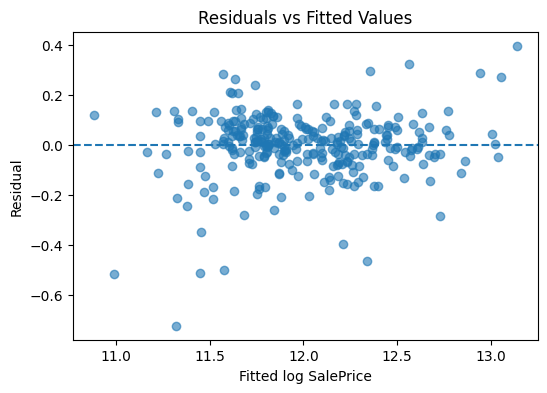

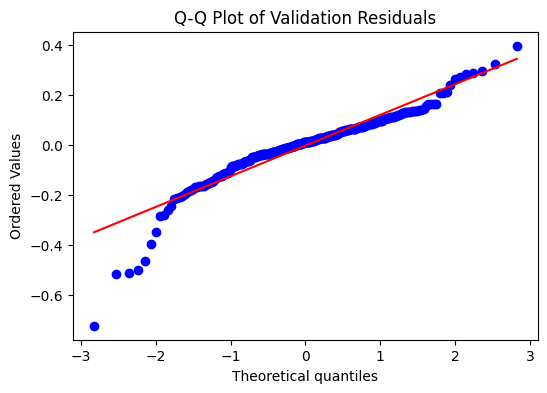

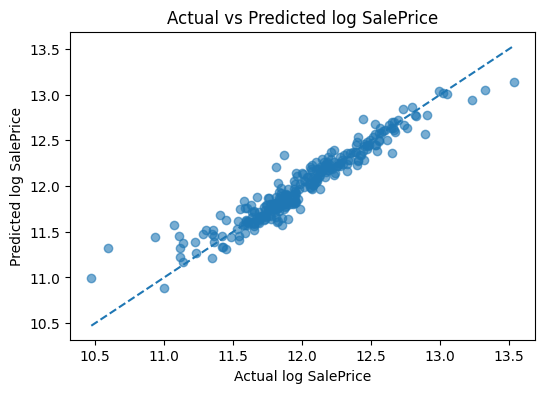

Jarque-Bera p-value: 0.0
Breusch-Pagan p-value: 0.03201


In [24]:
X_train_part, X_valid, y_train_log, y_valid_log, y_train_raw, y_valid_raw = train_test_split(
    X_model, y_log, y, test_size=0.2, random_state=42
)

best_name = cv_results.iloc[0]['Model']
best_model = models[best_name]
best_model.fit(X_train_part, y_train_log)
valid_pred_log = best_model.predict(X_valid)
valid_resid = y_valid_log - valid_pred_log
valid_rmse = rmse(y_valid_log, valid_pred_log)

print('Best model by CV:', best_name)
print('Validation log-RMSE:', round(valid_rmse, 5))
print('Residual mean:', round(valid_resid.mean(), 5))
print('Residual std:', round(valid_resid.std(), 5))
print('Residual skew:', round(stats.skew(valid_resid), 5))
print('Residual kurtosis:', round(stats.kurtosis(valid_resid), 5))

fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(valid_pred_log, valid_resid, alpha=0.6)
ax.axhline(0, linestyle='--')
ax.set_xlabel('Fitted log SalePrice')
ax.set_ylabel('Residual')
ax.set_title('Residuals vs Fitted Values')
plt.show()

fig, ax = plt.subplots(figsize=(6,4))
stats.probplot(valid_resid, dist='norm', plot=ax)
ax.set_title('Q-Q Plot of Validation Residuals')
plt.show()

fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(y_valid_log, valid_pred_log, alpha=0.6)
ax.plot([y_valid_log.min(), y_valid_log.max()], [y_valid_log.min(), y_valid_log.max()], linestyle='--')
ax.set_xlabel('Actual log SalePrice')
ax.set_ylabel('Predicted log SalePrice')
ax.set_title('Actual vs Predicted log SalePrice')
plt.show()

if HAS_STATSMODELS:
    jb_stat, jb_pvalue, skew, kurt = sm.stats.jarque_bera(valid_resid)
    print('Jarque-Bera p-value:', round(jb_pvalue, 5))
    bp_test = het_breuschpagan(valid_resid, sm.add_constant(valid_pred_log))
    print('Breusch-Pagan p-value:', round(bp_test[1], 5))
else:
    print('statsmodels not available; skipped Jarque-Bera and Breusch-Pagan tests.')

In [25]:
# Interpret Elastic Net coefficients if the model is fitted.
model_elasticnet.fit(X_model, y_log)
pre = model_elasticnet.named_steps['preprocess']
num_names = numeric_features
cat_names = list(pre.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features))
all_feature_names = np.array(num_names + cat_names)
selector = model_elasticnet.named_steps['select']
selected_names = all_feature_names[selector.get_support()]
elastic_coefs = model_elasticnet.named_steps['model'].coef_
interpret_df = pd.DataFrame({'feature': selected_names, 'coef': elastic_coefs})
interpret_df['abs_coef'] = interpret_df['coef'].abs()
print('Elastic Net alpha:', model_elasticnet.named_steps['model'].alpha_)
print('Elastic Net l1_ratio:', model_elasticnet.named_steps['model'].l1_ratio_)
display(interpret_df.sort_values('abs_coef', ascending=False).head(30))

# PCA interpretation summary
model_pcr_ridge.fit(X_model, y_log)
print('PCR retained components:', model_pcr_ridge.named_steps['pca'].n_components_)
print('PCR explained variance ratio:', round(model_pcr_ridge.named_steps['pca'].explained_variance_ratio_.sum(), 4))

Elastic Net alpha: 0.0004961947603002903
Elastic Net l1_ratio: 0.7


,feature,coef,abs_coef
48,MSZoning_C (all),-0.331829,0.331829
45,TotalSF_sq,-0.211191,0.211191
28,TotalSF,0.196151,0.196151
160,Functional_Maj2,-0.142530,0.142530
66,Neighborhood_Crawfor,0.133699,0.133699
40,Qual_x_TotalSF,0.098966,0.098966
77,Neighborhood_StoneBr,0.090368,0.090368
162,Functional_Typ,0.088761,0.088761
12,GrLivArea,0.080830,0.080830
72,Neighborhood_NoRidge,0.073346,0.073346


PCR retained components: 71
PCR explained variance ratio: 0.9512


### Findings Narrative

The log transformation improved model fit by reducing the strong right skew in SalePrice from 1.88 to 0.12 and aligning the analysis with Kaggle’s log-based evaluation. Cross-validation confirmed this improvement, with the log-transformed target producing a lower mean CV log-RMSE of 0.1309 compared with 0.1513 for the raw target. The engineered dichotomous variables captured structural housing differences such as garage, basement, fireplace, remodel status, and second-floor presence, while interaction and polynomial terms allowed quality, size, and age effects to vary nonlinearly. Subset investigation showed that using all predictors gave the best Ridge baseline CV log-RMSE of 0.1309, but a 200-feature subset remained competitive at 0.1324, supporting the value of regularization and feature selection. Among the two submitted models, Elastic Net Subset performed better, with a mean CV log-RMSE of 0.1330, compared with 0.1613 for PCR-Ridge. The Elastic Net model retained interpretability while shrinking weaker dummy variables and interactions; the strongest predictors included zoning, total square footage, living area, neighborhood indicators, quality-size interaction, kitchen quality, and house age. PCR-Ridge retained 71 principal components explaining 95.12% of predictor variance, but its weaker validation performance suggests that compressing predictors reduced some useful housing-price signal. Assumption checks for the best model showed a validation log-RMSE of 0.1288, near-zero residual mean, but nonnormal residuals and mild heteroscedasticity based on Jarque-Bera and Breusch-Pagan tests. Overall, Elastic Net was the stronger and more interpretable Kaggle submission, while PCR-Ridge provided a useful dimension-reduction comparison.